# Mini-Challenge: Intel Image Classification
**Deep Learning (DEL) – FHNW, FS26**  
Autor: Damian Szedalik

Aufgabe: Klassifikation von Naturszenen in 6 Kategorien
(buildings, forest, glacier, mountain, sea, street) mit einem CNN in PyTorch.  
Abgabe Erste Etappe: Basismodell, LR- und Batchsize-Tuning, Cross-Validation.

## 0. Setup & Imports

Alle externen Bibliotheken werden einmalig importiert. Der W&B API-Key wird aus der `.env`-Datei geladen (`WANDB_API_KEY=...`). `wandb.login()` muss einmalig pro Session aufgerufen werden.

In [17]:
import os
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch import Tensor
from torch.utils.data import DataLoader, SubsetRandomSampler
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

from sklearn.model_selection import KFold
import wandb
from dotenv import load_dotenv

load_dotenv()  # WANDB_API_KEY aus .env lesen

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

wandb.login()

Using device: mps


True

## 1. Datenexploration

6 Klassen: buildings, forest, glacier, mountain, sea, street.  
~14 034 Train- / 3 000 Test-Bilder, originale Auflösung: 150×150 px.  
Ziel: Klassenverteilung prüfen (Balanciertheit) und geeignetes Preprocessing ableiten.

In [18]:
data_root = Path("./data/Intel_Image_Classification")

train_root = data_root/"seg_train"/"seg_train"
test_root  = data_root/"seg_test"/"seg_test"
pred_root  = data_root/"seg_pred"/"seg_pred"

classes = sorted([d.name for d in train_root.iterdir() if d.is_dir()])

# Bilder pro Klasse/Split
train_counts = {cls: len(list((train_root / cls).glob("*.jpg"))) for cls in classes}
test_counts  = {cls: len(list((test_root  / cls).glob("*.jpg"))) for cls in classes}
pred_count   = len(list(pred_root.glob("*.jpg")))

for i in classes:
    print(f"{i}: {train_counts[i]} (Train), {test_counts[i]} (Test)")
print(f"Pred (unlabeled): {pred_count} Bilder")
print(f"Gesamt:           {sum(train_counts.values()) + sum(test_counts.values()) + pred_count} Bilder")

buildings: 2191 (Train), 437 (Test)
forest: 2271 (Train), 474 (Test)
glacier: 2404 (Train), 553 (Test)
mountain: 2512 (Train), 525 (Test)
sea: 2274 (Train), 510 (Test)
street: 2382 (Train), 501 (Test)
Pred (unlabeled): 7301 Bilder
Gesamt:           24335 Bilder


In [19]:
# Get train and test images separately
train_imgs = list(train_root.rglob("*.jpg"))
test_imgs = list(test_root.rglob("*.jpg"))

for split_name, imgs in [("Train", train_imgs), ("Test", test_imgs)]:
    # Get resolutions
    resolutions = (Image.open(p).size for p in imgs)
    widths, heights = zip(*resolutions)

    # Get and print resolution statistics
    print(f"Auflösungsstatistik für {len(imgs)} {split_name}-Bilder:")
    print(f"  Breite – min, max: {min(widths)}, {max(widths)}")
    print(f"  Höhe   – min, max: {min(heights)}, {max(heights)}\n")

Auflösungsstatistik für 14034 Train-Bilder:
  Breite – min, max: 150, 150
  Höhe   – min, max: 76, 150

Auflösungsstatistik für 3000 Test-Bilder:
  Breite – min, max: 150, 150
  Höhe   – min, max: 72, 150



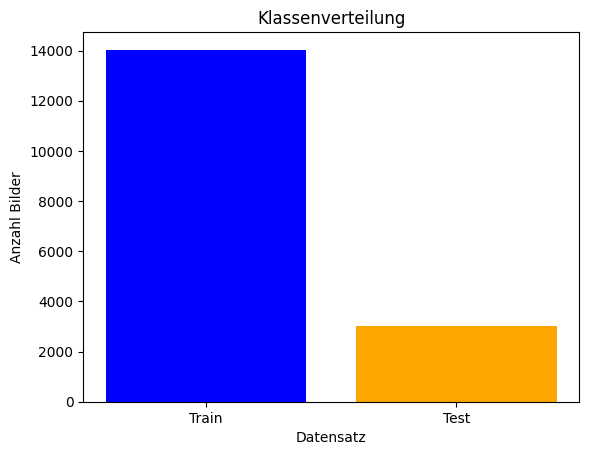

In [20]:
plt.bar(['Train', 'Test'], [len(train_imgs), len(test_imgs)], color=['blue', 'orange'])
plt.ylabel('Anzahl Bilder')
plt.xlabel('Datensatz')
plt.title('Klassenverteilung')
plt.show()

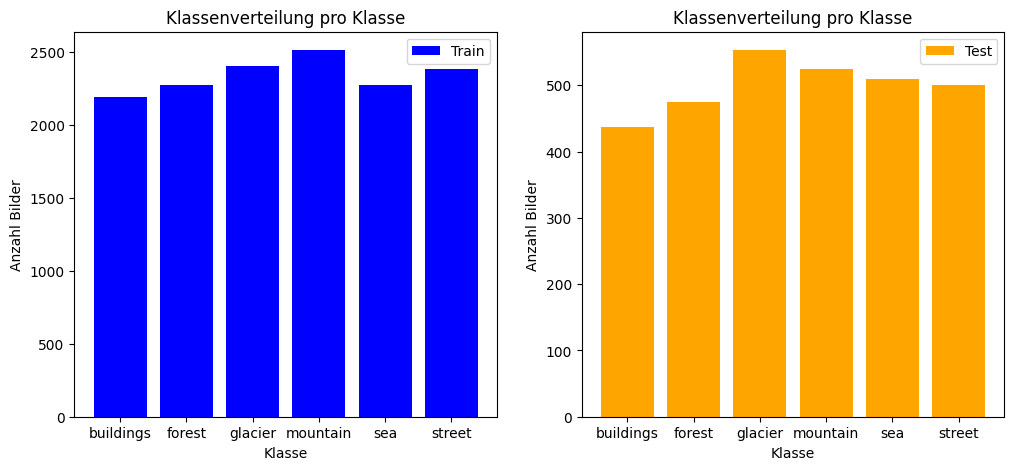

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(classes, train_counts.values(), label='Train', color='blue')
axes[1].bar(classes, test_counts.values(), label='Test', color='orange')
axes[0].set_ylabel('Anzahl Bilder')
axes[0].set_xlabel('Klasse')
axes[1].set_ylabel('Anzahl Bilder')
axes[1].set_xlabel('Klasse')
axes[0].set_title('Klassenverteilung pro Klasse')
axes[1].set_title('Klassenverteilung pro Klasse')
axes[0].legend()
axes[1].legend()
plt.show()

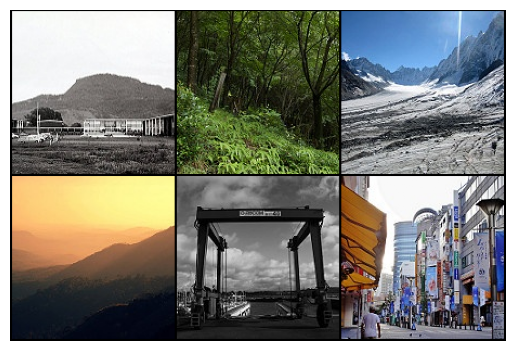

In [22]:
img_examples = ImageFolder(
    root=train_root,
    transform=transforms.ToTensor()
)
imgs = [img_examples[img_examples.targets.index(i)][0] for i in range(len(classes))]

grid = torchvision.utils.make_grid(imgs, nrow=3)

plt.imshow(grid.permute(1,2,0))
plt.axis("off")
plt.show()

Gegebener Train-Test-Split ist passend mit ca. 80/20 Split. Die Klassenverteilung ist okay, jede Klasse im Train-Datensatz hat 2191-2512 Bilder drin.

## 2. Preprocessing & DataLoader

Alle Bilder werden auf 64×64 px skaliert und als Float-Tensor normiert (ToTensor → [0, 1]).  
DataLoader mit konfigurierbarer Batchgrösse.

In [23]:
def compute_dataset_stats(dataset: ImageFolder) -> tuple[list[float], list[float]]:
    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2)
    channel_sum    = torch.zeros(3)
    channel_sum_sq = torch.zeros(3)
    n_pixels = 0

    for imgs, _ in loader:
        channel_sum    += imgs.sum(dim=[0, 2, 3])
        channel_sum_sq += (imgs ** 2).sum(dim=[0, 2, 3])
        n_pixels       += imgs.size(0) * imgs.size(2) * imgs.size(3)

    mean = channel_sum / n_pixels
    std  = (channel_sum_sq / n_pixels - mean ** 2).sqrt()
    return mean.tolist(), std.tolist()

def get_transforms(img_size: int, mean: list[float], std: list[float]) -> transforms.Compose:
    """
    Pixel-Werte im Bereich [0.0, 1.0]
    """
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

# Klassen-Mapping
def get_datasets(train_root, test_root, transform) -> tuple[ImageFolder, ImageFolder]:
    train_ds = ImageFolder(root=train_root, transform=transform)
    test_ds  = ImageFolder(root=test_root,  transform=transform)
    return train_ds, test_ds

def get_dataloaders(train_ds, test_ds, batch_size: int, num_workers: int = 2):
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, test_loader

In [ ]:
TARGET_SIZE = 64

# Dataset Normalize laden (nur für Statistik-Berechnung)
transform_raw = get_transforms(TARGET_SIZE, mean=[0, 0, 0], std=[1, 1, 1])
train_ds_raw, _ = get_datasets(train_root, test_root, transform_raw)

# Pro Kanal Mean und Std auf Trainset berechnen
mean, std = compute_dataset_stats(train_ds_raw)
print(f"Mean: {mean}")
print(f"Std:  {std}")

# Transform mit Normalize
transform = get_transforms(TARGET_SIZE, mean=mean, std=std)

# Finale Datasets + DataLoader mit normalisierten Daten
train_ds, test_ds = get_datasets(train_root, test_root, transform)
train_loader, test_loader = get_dataloaders(train_ds, test_ds, batch_size=32)

imgs, labels = next(iter(train_loader))
print(f"Batch shape: {imgs.shape}")
print(f"Klassen: {train_ds.classes}")

Mean: [0.43018341064453125, 0.4574870467185974, 0.45385730266571045]
Std:  [0.24802614748477936, 0.24667836725711823, 0.28059622645378113]
Batch shape: torch.Size([32, 3, 64, 64])
Klassen: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## 3. Metriken

Kostenfunktion: CrossEntropyLoss.  
Metrik: Accuracy (Anteil korrekt klassifizierter Bilder).  
Beide werden pro Epoche berechnet und an W&B geloggt.

In [ ]:
def compute_accuracy(outputs: Tensor, labels: Tensor) -> float:
    """
    Fraction of correctly classified samples: sum(argmax(outputs) == labels) / N.
    """
    preds = outputs.argmax(dim=1)
    correct = preds.eq(labels)
    accuracy = correct.float().mean().item()
    return accuracy

## 4. Modell-Architektur

### Intel Image Classification Datenset:
(6 Klassen: buildings, forest, glacier, mountain, sea, street)

RGB-Bilder, auf 64×64 px skaliert -> Tensor der Form [3, 64, 64]

https://www.kaggle.com/datasets/puneet6060/intel-image-classification/data

**Task:** Bildklassifikation auf dem Intel Image Classification Dataset 

### Architektur:
| Block              | Layer                                                       | Parameter  |
| ------------------ | ----------------------------------------------------------- | ---------- |
| Feature Extraction | Conv2d(3 -> 32, kernel=3, padding=1) + ReLU + MaxPool(2×2)   | 32 Filter  |
| Feature Extraction | Conv2d(32 -> 64, kernel=3, padding=1) + ReLU + MaxPool(2×2)  | 64 Filter  |
| Feature Extraction | Conv2d(64 -> 128, kernel=3, padding=1) + ReLU + MaxPool(2×2) | 128 Filter |
| Classification     | Flatten -> Linear(8192 -> 256) + ReLU                         | 256 Units  |
| Classification     | Linear(256 -> 6)                                             | 6 Ausgaben |

### Training:
- Dropout?
- Batchsize tuning?
- argmax oder softmax?
- Data Augmentation -> 2x aus originalbild raus schneiden

- Optimizer: SGD
- Loss: CrossEntropyLoss
- Keine Regularisierung, kein BatchNorm, kein Dropout
- Lernrate und (Batchsize) werden manuell getuned

In [ ]:
# class BaseCNN(nn.Module):
#   __init__(self, num_classes: int, conv_channels: list[int], fc_units: int,
#            img_size: int = 64):
#     conv_channels = [32, 64, 128] → 3× (Conv2d + ReLU + MaxPool(2×2))
#     flatten_size = conv_channels[-1] * (img_size // 2**len(conv_channels))**2
#     → für [32,64,128] und img_size=64: 128 * 8 * 8 = 8192 (dynamisch, nicht hardcoded)
#     fc: Linear(flatten_size → fc_units) + ReLU → Linear(fc_units → num_classes)
#   forward(self, x: Tensor) -> Tensor
#     Rückgabe: rohe Logits, shape [B, num_classes] — kein Softmax (CrossEntropyLoss erwartet das)

# build_model(num_classes, conv_channels, fc_units, device, img_size=64) -> BaseCNN
#   Rückgabe: BaseCNN(...).to(device) — Modell auf korrektem Device

## 5. Trainings- und Evaluationsinfrastruktur

Die folgenden Funktionen bilden den vollständigen Trainingszyklus.  
Alle Runs werden an W&B geloggt. Die `train()`-Funktion gibt den Run-URL aus,  
damit die Ergebnisse direkt im Dashboard nachverfolgt werden können.

In [ ]:
# get_optimizer(model: nn.Module, lr: float) -> torch.optim.SGD
#   Rückgabe: SGD(model.parameters(), lr=lr, momentum=0)
#   (Etappe 1: ausschliesslich SGD ohne Momentum, gemäss Aufgabenstellung)

# get_criterion() -> nn.CrossEntropyLoss
#   Rückgabe: CrossEntropyLoss() — kombiniert LogSoftmax + NLLLoss

In [ ]:
# train_one_epoch(model, loader, optimizer, criterion, device) -> tuple[float, float]
#   model.train() → Batch-Loop → loss.backward() → optimizer.step()
#   Rückgabe: (avg_loss, avg_acc) — Durchschnitt über alle Batches der Epoche
#   avg_loss: mittlerer CrossEntropyLoss (float > 0)
#   avg_acc:  mittlere Accuracy [0.0, 1.0]

In [ ]:
# evaluate(model, loader, criterion, device) -> tuple[float, float]
#   model.eval() + torch.no_grad() — keine Gradientenberechnung
#   Rückgabe: (avg_loss, avg_acc) — gleiche Semantik wie train_one_epoch

In [ ]:
# train(config: dict, train_loader, val_loader, device) -> dict
#   wandb.init(project="del-intel-clf", name=f"lr{config['lr']}_bs{config['batch_size']}",
#              group=config.get("group", "etappe1"), config=config)
#   pro Epoche:
#     train_loss, train_acc = train_one_epoch(...)
#     val_loss, val_acc     = evaluate(...)
#     wandb.log({"epoch": e, "train/loss": train_loss, "train/acc": train_acc,
#                "val/loss": val_loss, "val/acc": val_acc})
#   print(f"W&B Run: {wandb.run.url}")  ← Link zum Run im Dashboard
#   wandb.finish()  [in finally-Block]
#   Rückgabe: {"train_loss": [...], "val_loss": [...], "train_acc": [...], "val_acc": [...],
#              "run_url": str}

In [ ]:
# plot_learning_curves(histories: dict[str, dict], title: str = "") -> None
#   Rückgabe: None — zeigt matplotlib-Figure direkt im Notebook an
#   Zwei Subplots nebeneinander:
#     links:  Train/Val Loss über Epochen (für jeden Run in histories)
#     rechts: Train/Val Accuracy über Epochen
#   Aufruf für Grid-Search: plot_learning_curves({"lr=0.01": h1, "lr=0.001": h2, ...})

## 6. Overfitting-Test (Sanity Check)

Das Modell wird auf einem einzigen Batch übertrainiert.  
**Erwartung:** Loss → 0, Accuracy = 100 % nach wenigen Epochen.  
Bestätigt korrekte Forward- und Backward-Propagation.  
Falls der Test fehlschlägt → Bug in `BaseCNN.forward()` oder `train_one_epoch()` suchen.

In [ ]:
# overfit_single_batch(model, loader, optimizer, criterion, device, n_epochs=50) -> None
#   Rückgabe: None — gibt Loss pro Epoche auf stdout aus + zeigt Loss-Kurve im Notebook
#   Nimmt einen einzigen Batch aus loader, trainiert ausschliesslich darauf
#   Kein W&B-Logging (wandb.init(mode="disabled") oder keinen init)
#   Erwartung: Loss < 0.01, Accuracy = 1.0 nach n_epochs

## 7. Lernraten-Tuning

Der Einfluss der Lernrate wird mit manuellem Grid-Search untersucht.  
Alle anderen Parameter fix: `batch_size=32`, SGD ohne Momentum, `num_epochs=20`.

**Erwartung (Theorie):**  
- Zu kleine LR → langsame Konvergenz  
- Zu grosse LR → instabiler Loss, Divergenz  
- Optimale LR → schnelle und stabile Konvergenz  

*Bemerkung: Keine automatischen Hyperparameter-Suchverfahren — manueller Grid-Search gemäss Aufgabenstellung.*

In [ ]:
# lr_values = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 1e-1]
# all_histories = {}
#
# für jede lr in lr_values:
#   config = {"lr": lr, "batch_size": 32, "num_epochs": 20,
#             "num_classes": 6, "conv_channels": [32, 64, 128], "fc_units": 256,
#             "group": "etappe1-lr-tuning"}
#   model     = build_model(config["num_classes"], config["conv_channels"],
#                           config["fc_units"], device)
#   optimizer = get_optimizer(model, lr)
#   history   = train(config, train_loader, test_loader, device)
#   all_histories[f"lr={lr}"] = history
#   → Run-URL wird automatisch durch train() gedruckt
#
# plot_learning_curves(all_histories, title="Lernraten-Vergleich")

**Interpretation:**  
*[Platzhalter — Welche Lernrate wurde gewählt? Begründung anhand der Lernkurven. Entspricht das Verhalten der theoretischen Erwartung?]*

## 8. Batchsize-Tuning

Mit der gewählten optimalen Lernrate wird der Einfluss der Batchsize untersucht.

**Erwartung (Theorie):**  
- Kleine Batchsize → stochastischere Gradienten, mögliche Regularisierungswirkung  
- Grosse Batchsize → stabilere Gradienten, evtl. schlechtere Generalisierung (Sharp Minima)

In [ ]:
# batch_sizes = [16, 32, 64, 128]
# all_histories_bs = {}
#
# für jede bs in batch_sizes:
#   config = {"lr": <beste_lr>, "batch_size": bs, "num_epochs": 20,
#             "num_classes": 6, "conv_channels": [32, 64, 128], "fc_units": 256,
#             "group": "etappe1-bs-tuning"}
#   train_loader_bs, test_loader_bs = get_dataloaders(train_ds, test_ds, bs)
#   model     = build_model(config["num_classes"], config["conv_channels"],
#                           config["fc_units"], device)
#   optimizer = get_optimizer(model, config["lr"])
#   history   = train(config, train_loader_bs, test_loader_bs, device)
#   all_histories_bs[f"bs={bs}"] = history
#   → Run-URL wird automatisch durch train() gedruckt
#
# plot_learning_curves(all_histories_bs, title="Batchsize-Vergleich")

**Interpretation:**  
*[Platzhalter — Welche Batchsize wurde gewählt? Einfluss auf Konvergenzgeschwindigkeit und finale Accuracy?]*

## 9. Statistische Fehlerabschätzung (Cross-Validation)

k=5-Fold Cross-Validation auf dem Trainingsdatensatz.  
Pro Fold wird das Modell neu initialisiert und auf k-1 Folds trainiert,  
dann auf dem Validierungs-Fold evaluiert.  
Aus den k Accuracy-Werten werden Mittelwert ± Standardabweichung berechnet.

*Verwendete Hyperparameter: beste LR und Batchsize aus Schritten 7 und 8.*

In [ ]:
# run_cross_validation(dataset, config: dict, device, n_splits: int = 5) -> dict
#   KFold(n_splits, shuffle=True, random_state=42)
#   pro Fold:
#     SubsetRandomSampler für Train/Val-Indizes → DataLoader
#     build_model → get_optimizer → train_one_epoch-Schleife (kein wandb.init pro Fold)
#   Rückgabe: {"fold_accuracies": list[float], "mean_acc": float, "std_acc": float}
#
# Ausgabe: Tabelle der Fold-Accuracies + Boxplot / Balkendiagramm mit Fehlerbalken

**Interpretation:**  
*[Platzhalter — Mittelwert ± Standardabweichung. Wie gross ist die Varianz? Was sagt das über die Stabilität/Generalisierbarkeit des Basismodells?]*

## 10. Fazit Erste Etappe

*[Platzhalter — nach Durchführung ausfüllen:]*

- **Gewählte finale Hyperparameter:** lr = ..., batch_size = ...
- **Erzielte Test-Accuracy:** ...
- **Statistische Fehlerabschätzung:** mean_acc ± std_acc
- **Beobachtungen zu Lernkurven und Trainingsverhalten:** ...
- **W&B-Projektdashboard:** [del-intel-clf auf W&B](...)